In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from features.Carl import (
           total_number_of_sessions,
           time_last_used,
           feature_total_pages_count,
           exact_device_type,
           num_status,
           gender_feature_ont_hot,
           location_state_one_hot_encoded,
           member_since,
           num_different_songs,
           num_different_artists,
           weekly_length_features,
           feature_page_dynamic)



from pipeline import (create_X_y_df,
                      create_1_week_X_y_df,
                      create_2_week_X_y_df,
                      create_3_week_X_y_df,
                      create_1_week_X_y_df_test,
                      create_2_week_X_y_df_test,
                      create_3_week_X_y_df_test)

import numpy as np

import datetime

from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from xgboost import XGBClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report
from kaggle.api.kaggle_api_extended import KaggleApi

In [2]:
np.random.seed(42)

# Loading Data and Creating Features

In [3]:
full_dataset_df = pd.read_parquet("../../../data/churn-prediction-25-26/train.parquet")

In [4]:
full_dataset_df.sample(10)

,status,gender,firstName,level,lastName,userId,ts,auth,page,sessionId,location,itemInSession,userAgent,method,length,song,artist,time,registration
8415245,200,M,August,paid,Clark,1207487,1540518498000,Logged In,NextSong,112798,"Riverside-San Bernardino-Ontario, CA",400,Mozilla/5.0 (Windows NT 6.1; Trident/7.0; rv:1...,PUT,236.04200,Hostile [Live Version],Pantera,2018-10-26 01:48:18,2018-09-10 17:03:47
12828473,200,F,Alani,paid,Kane,1325330,1541672419000,Logged In,NextSong,159518,"Tampa-St. Petersburg-Clearwater, FL",74,Mozilla/5.0 (Windows NT 6.1; rv:31.0) Gecko/20...,PUT,194.03710,Karibien,Air France,2018-11-08 10:20:19,2018-09-05 06:02:19
13490632,200,F,Angelina,paid,Singh,1495032,1541826321000,Logged In,NextSong,174513,"Santa Maria-Santa Barbara, CA",216,"""Mozilla/5.0 (iPhone; CPU iPhone OS 7_1_2 like...",PUT,278.07302,Through The Wire,Kanye West,2018-11-10 05:05:21,2018-08-24 13:24:27
9329450,200,M,Nathaniel,paid,Norris,1525270,1540794304000,Logged In,NextSong,128771,"San Francisco-Oakland-Hayward, CA",120,"""Mozilla/5.0 (Macintosh; Intel Mac OS X 10_9_4...",PUT,132.85832,Ride A White Swan,T. Rex,2018-10-29 06:25:04,2018-06-23 13:42:06
13901146,200,M,Landyn,paid,Evans,1849720,1541985370000,Logged In,NextSong,179047,"Atlanta-Sandy Springs-Roswell, GA",74,"""Mozilla/5.0 (Macintosh; Intel Mac OS X 10_9_4...",PUT,266.65751,Black Planet (Remastered),Sisters Of Mercy,2018-11-12 01:16:10,2018-08-25 21:44:42
930473,200,F,Alondra,paid,Johnson,1981365,1538601966000,Logged In,NextSong,35505,"Houston-The Woodlands-Sugar Land, TX",255,Mozilla/5.0 (Macintosh; Intel Mac OS X 10.6; r...,PUT,579.83955,Kalopsia,Mark Otten,2018-10-03 21:26:06,2018-08-26 05:10:08
23244814,200,F,Georgia,paid,Walsh,1558947,1538958297000,Logged In,NextSong,7989,"Dallas-Fort Worth-Arlington, TX",12,"""Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/5...",PUT,201.79546,Revelry,Kings Of Leon,2018-10-08 00:24:57,2018-09-10 19:59:11
9200665,200,M,Jadon,paid,Benitez,1999781,1540750023000,Logged In,NextSong,132052,"San Diego-Carlsbad, CA",49,Mozilla/5.0 (Macintosh; Intel Mac OS X 10.9; r...,PUT,98.14159,Samba De Una Nota SoÃÂ´,Joa~o Gilberto,2018-10-28 18:07:03,2018-08-31 02:26:28
5698983,200,F,Fatima,free,Hancock,1460110,1539845728000,Logged In,NextSong,74377,"New York-Newark-Jersey City, NY-NJ-PA",12,"""Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebK...",PUT,244.47955,Chana Masala,Looptroop,2018-10-18 06:55:28,2018-09-06 14:24:41
7062194,200,M,James,paid,Carlson,1588321,1540221175000,Logged In,NextSong,107607,"Cleveland-Elyria, OH",11,Mozilla/5.0 (X11; Ubuntu; Linux x86_64; rv:31....,PUT,218.27873,Tonight,FM Static,2018-10-22 15:12:55,2018-09-25 02:33:43


In [5]:
full_dataset_df.columns

Index(['status', 'gender', 'firstName', 'level', 'lastName', 'userId', 'ts',
       'auth', 'page', 'sessionId', 'location', 'itemInSession', 'userAgent',
       'method', 'length', 'song', 'artist', 'time', 'registration'],
      dtype='object')

In [6]:
full_dataset_df["page"].unique()

# Downgrad
# Help
# Thumbs Up -> 3
# Add Friend  -> 3
# Thumbs Down -> 3
# Add to Playlist -> 2
# Submit Downgrade -> 3
# Roll Advert -> 2
# Upgrade -> 3 -> do not understand
# Error -> 3
# Submit Upgrade -> 3

array(['NextSong', 'Downgrade', 'Help', 'Home', 'Thumbs Up', 'Add Friend',
       'Thumbs Down', 'Add to Playlist', 'Logout', 'About', 'Settings',
       'Save Settings', 'Cancel', 'Cancellation Confirmation',
       'Submit Downgrade', 'Roll Advert', 'Upgrade', 'Error',
       'Submit Upgrade'], dtype=object)

'status' -> check error pages

'page' -> check which pages the user visist for immportant ones track progress

'sessionId' -> sessions per day

'itemInSession' -> number of items per session

'song' -> number of different songs listened to

'artist' -> number of different artists listened to

Also: 
- mean gap between two sessions per week 

In [7]:
NUM_WEEK_TRAIN = 3
SUBMISSION_WEEK_SLICE = 3

TRAIN_WEEK_SLICES = [0]
TEST_WEEK_SLICES = [1]

In [8]:
if NUM_WEEK_TRAIN == 1:
    df_X_slice_list, df_y_slice_list = create_1_week_X_y_df(df = full_dataset_df)
elif NUM_WEEK_TRAIN == 2:
    df_X_slice_list, df_y_slice_list = create_2_week_X_y_df(df = full_dataset_df)
elif NUM_WEEK_TRAIN == 3:
    df_X_slice_list, df_y_slice_list = create_3_week_X_y_df(df = full_dataset_df)
else:
    df_X_slice_list, df_y_slice_list = None, None

In [9]:
"""
['NextSong', 'Downgrade', 'Help', 'Home', 'Thumbs Up', 'Add Friend',
       'Thumbs Down', 'Add to Playlist', 'Logout', 'About', 'Settings',
       'Save Settings', 'Submit Downgrade', 'Roll Advert', 'Upgrade',
       'Error', 'Submit Upgrade']
"""

"\n['NextSong', 'Downgrade', 'Help', 'Home', 'Thumbs Up', 'Add Friend',\n       'Thumbs Down', 'Add to Playlist', 'Logout', 'About', 'Settings',\n       'Save Settings', 'Submit Downgrade', 'Roll Advert', 'Upgrade',\n       'Error', 'Submit Upgrade']\n"

In [ ]:
def create_feature_engineered_df(df):
    feature_total_pages_count_df = feature_total_pages_count(df) # over the whole time slice this feature returns the total number of vistis on each page
    total_number_of_sessions_df = total_number_of_sessions(df) # over the whole time slice this feature returns the total number of vistis on each page

    # devides the whole time slice into the weeks and for each user computes the
    # total time listening to music
    # computes the deltas between the weeks
    # computes the mean of the deltas to get an idea of the gradient
    # computes the variance of the deltas to get a sense of the fluctuations in usage

    # computes the percentage decreases of the deltas between each week
    # computes the mean percentage increase or decrease to get an idea of the per user scaled gradient
    # computes the variance percentage to get an idea of the per user scaled usage fluctuations
    weekly_length_features_df = weekly_length_features(df)

    # computes the last time a person has used the application
    time_last_used_df = time_last_used(df)

    # computes the number of 200, 307 or 404 responses per person
    num_status_df = num_status(df)

    # computes the exact device type each user is using.
    # Each user is only using one device and is not changing their device
    # differentiates between: Iphone, Macintsh, Linux and Windows and computes
    # One hot encoding for each
    device_type_df = exact_device_type(df)

    # One Hot encodes the gender of the user
    gender_feature_ont_hot_df = gender_feature_ont_hot(df)

    # one Hot encodes the location of the user.
    # they are all in the US and we thus get a one hot encoding based on if they are in
    # one of the 50 states of the us
    location_state_one_hot_encoded_df = location_state_one_hot_encoded(df)

    # computes the number of days a user has been a registered
    member_since_df = member_since(df)

    # computes the numbe of different songs listend to by the user in total
    num_different_songs_df = num_different_songs(df)

    # compute the number of different artistst listeend to by the user in total
    num_different_artists_df = num_different_artists(df)


    # All the followign features are similar to the  weekly_length_features_df
    # feature. Here we however do not consider the total time spend per week
    # but instaed compute their count of visiting each page
    # Next Song -> click on Next Song
    # Downgrad -> Cancel Premium Subscription
    # Help -> Need Help
    # Home -> Visit the Home Page
    # Thumbs Up -> Liking a Song
    # Add Friend -> Adding a Friend
    # Thumbs Down -> Disliking a Song
    # Add to Playlist -> Add Song to Playlist
    # About -> About section of our Service
    # Settings -> System Settings
    # Save Settings -> Saving System Settings
    # Submit Downgrade -> Submit their ending of the paid subscirption (this is not considered churn!)
    # Roll Advert -> Look at an Advert
    # Upgrade -> Entering a Paid Subscription
    # Error -> They have an Error
    # Submit Upgrade -> They submit their upgrade for the paid subscription model
    feature_page_dynamic_next_song_df = feature_page_dynamic(df, page="Next Song")
    feature_page_dynamic_downgrade_df = feature_page_dynamic(df, page="Downgrade")
    feature_page_dynamic_help_df = feature_page_dynamic(df, page="Help")
    feature_page_dynamic_home_df = feature_page_dynamic(df, page="Home")
    feature_page_dynamic_thumbs_up_df = feature_page_dynamic(df, page="Thumbs Up")
    feature_page_dynamic_add_friend_df = feature_page_dynamic(df, page="Add Friend")
    feature_page_dynamic_thumbs_down_df = feature_page_dynamic(df, page="Thumbs Down")
    feature_page_dynamic_add_to_playlist_df = feature_page_dynamic(df, page="Add to Playlist")
    feature_page_dynamic_about_df = feature_page_dynamic(df, page="About")
    feature_page_dynamic_settings_df = feature_page_dynamic(df, page="Settings")
    feature_page_dynamic_save_settings_df = feature_page_dynamic(df, page="Save Settings")
    feature_page_dynamic_submit_downgrade_df = feature_page_dynamic(df, page="Submit Downgrade")
    feature_page_dynamic_roll_advert_df = feature_page_dynamic(df, page="Roll Advert")
    feature_page_dynamic_upgrade_df = feature_page_dynamic(df, page="Upgrade")
    feature_page_dynamic_error_df = feature_page_dynamic(df, page="Error")
    feature_page_dynamic_submit_upgrade_df = feature_page_dynamic(df, page="Submit Upgrade")


    df = feature_total_pages_count_df.merge(total_number_of_sessions_df, on = "userId")
    df = df.merge(weekly_length_features_df, on = "userId")
    df = df.merge(time_last_used_df, on = "userId")
    df = df.merge(num_status_df, on = "userId")
    df = df.merge(device_type_df, on = "userId")
    df = df.merge(gender_feature_ont_hot_df, on = "userId")
    df = df.merge(member_since_df, on = "userId")
    df = df.merge(feature_page_dynamic_thumbs_up_df, on = "userId")
    df = df.merge(feature_page_dynamic_add_friend_df, on = "userId")
    df = df.merge(feature_page_dynamic_thumbs_down_df, on = "userId")
    df = df.merge(feature_page_dynamic_add_to_playlist_df, on = "userId")
    df = df.merge(feature_page_dynamic_submit_downgrade_df, on = "userId")
    df = df.merge(feature_page_dynamic_roll_advert_df, on = "userId")
    df = df.merge(feature_page_dynamic_upgrade_df, on = "userId")
    df = df.merge(feature_page_dynamic_error_df, on = "userId")
    df = df.merge(feature_page_dynamic_submit_upgrade_df, on = "userId")
    df = df.merge(feature_page_dynamic_help_df, on = "userId")
    df = df.merge(feature_page_dynamic_downgrade_df, on = "userId")

    return df

In [11]:
df_X_feature_slice_list = []

for df_X_slice in df_X_slice_list:
    df_X_feature_slice = create_feature_engineered_df(df_X_slice)
    df_X_feature_slice_list.append(df_X_feature_slice)

# Train/Test Split based on weeks

In [12]:

def create_X_train_X_test_y_train_y_test(df_X_feature_slice_list,
                                         df_y_slice_list,
                                         train_slices_index_list,
                                         test_slices_index_list):

    df_X_list = []
    df_y_list = []

    for df_X_feature_slice, df_y_slice in zip(df_X_feature_slice_list, df_y_slice_list):
        df_X_y = df_X_feature_slice.merge(df_y_slice, on = ["userId"])

        # remove the userId
        columns_X = df_X_feature_slice.columns.drop(["userId"])
        columns_y = ["Cancellation Confirmation"]

        # Remove identifier column before scaling/modeling
        X = df_X_y[columns_X]
        y = df_X_y[columns_y]

        df_X_list.append(X)
        df_y_list.append(y)

    X_train_slices = [df_X_list[i] for i in train_slices_index_list]
    y_train_slices = [df_y_list[i] for i in train_slices_index_list]
    X_test_slices  = [df_X_list[i] for i in test_slices_index_list]
    y_test_slices  = [df_y_list[i] for i in test_slices_index_list]

    df_X_train = pd.concat(X_train_slices, axis=0, ignore_index=True)
    df_y_train = pd.concat(y_train_slices, axis=0, ignore_index=True)
    df_X_test  = pd.concat(X_test_slices,  axis=0, ignore_index=True)
    df_y_test  = pd.concat(y_test_slices,  axis=0, ignore_index=True)

    return df_X_train, df_X_test, df_y_train, df_y_test

In [13]:
df_X_train, df_X_test, df_y_train, df_y_test = create_X_train_X_test_y_train_y_test(
    df_X_feature_slice_list=df_X_feature_slice_list,
    df_y_slice_list=df_y_slice_list,
    train_slices_index_list=TRAIN_WEEK_SLICES,
    test_slices_index_list=TEST_WEEK_SLICES
)

y_train = df_y_train["Cancellation Confirmation"].ravel()
y_test = df_y_test["Cancellation Confirmation"].ravel()

/var/folders/kn/2hccvkp11655sjfyptcwpt0h0000gn/T/ipykernel_2115/523939622.py:8: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  y_train = df_y_train["Cancellation Confirmation"].ravel()
/var/folders/kn/2hccvkp11655sjfyptcwpt0h0000gn/T/ipykernel_2115/523939622.py:9: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  y_test = df_y_test["Cancellation Confirmation"].ravel()


# Model Training

ROC AUC: 0.5508158475214738
[[12256  1238]
 [  360    49]]
              precision    recall  f1-score   support

           0       0.97      0.91      0.94     13494
           1       0.04      0.12      0.06       409

    accuracy                           0.89     13903
   macro avg       0.50      0.51      0.50     13903
weighted avg       0.94      0.89      0.91     13903



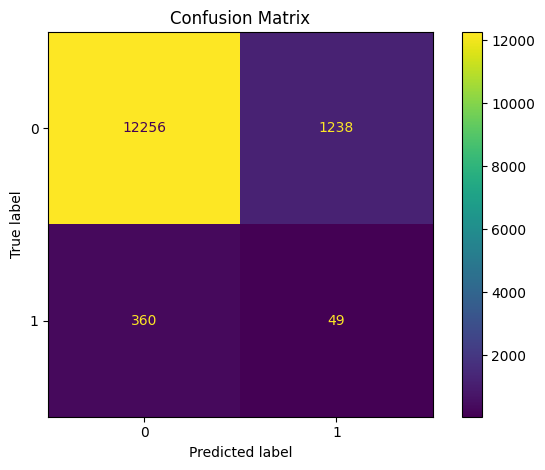

In [44]:
from sklearn.metrics import roc_auc_score

num_cols = df_X_train.select_dtypes(include=["int64", "float64"]).\
    columns.tolist()


cat_cols = df_X_train.select_dtypes(include=["object"]).\
    columns.tolist()


# 2) Preprocess: impute + one-hot for categoricals, impute for numerics
categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))  # use sparse output by default
])

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

preprocess = ColumnTransformer(
    transformers=[
        ("cat", categorical_pipeline, cat_cols),
        ("num", numeric_pipeline, num_cols),
    ]
    #remainder="passthrough"
)

n_pos = np.sum(y_train == 1)
n_neg = np.sum(y_train == 0)
spw = n_neg / max(n_pos, 1)

xgb = XGBClassifier(scale_pos_weight = spw)#, eval_metric="aucpr")
#xgb = XGBClassifier()

# 4) Full pipeline
clf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", xgb)
])

clf.fit(df_X_train, y_train)
pred = clf.predict(df_X_test)

y_score = clf.predict_proba(df_X_test)[:, 1]   # probability of class 1
auc = roc_auc_score(y_test, y_score)
print("ROC AUC:", auc)

# numeric matrix
cm = confusion_matrix(y_test, pred)
print(cm)

print(classification_report(y_test, pred))

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(values_format="d")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()



ROC AUC: 0.37440727980886546
[[13494     0]
 [  409     0]]
              precision    recall  f1-score   support

           0       0.97      1.00      0.99     13494
           1       0.00      0.00      0.00       409

    accuracy                           0.97     13903
   macro avg       0.49      0.50      0.49     13903
weighted avg       0.94      0.97      0.96     13903



/Users/aaron/anaconda3/envs/pfds/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/aaron/anaconda3/envs/pfds/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/aaron/anaconda3/envs/pfds/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

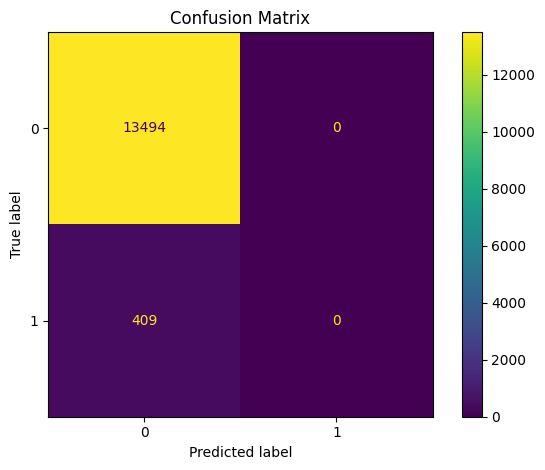

In [43]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    roc_auc_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
)

# -----------------------------
# 1) Columns
# -----------------------------
num_cols = df_X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = df_X_train.select_dtypes(include=["object"]).columns.tolist()

# -----------------------------
# 2) Preprocess: impute + one-hot for categoricals, impute for numerics
# -----------------------------
categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

preprocess = ColumnTransformer(
    transformers=[
        ("cat", categorical_pipeline, cat_cols),
        ("num", numeric_pipeline, num_cols),
    ]
)

# -----------------------------
# 3) Class imbalance -> class_weight (equivalent spirit to scale_pos_weight)
# -----------------------------
n_pos = np.sum(y_train == 1)
n_neg = np.sum(y_train == 0)
spw = n_neg / max(n_pos, 1)  # your ratio
class_weight = {0: 1.0, 1: 8.5}  # or use "balanced"
#print(spw)

# -----------------------------
# 4) Pick a model
# -----------------------------
logreg = LogisticRegression(
    solver="saga",          # good with sparse one-hot
    max_iter=5000,
    class_weight=class_weight,
    #class_weight="balanced",
    n_jobs=-1
)

rf = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    class_weight="balanced_subsample",   # or "balanced_subsample"
    n_jobs=-1
)

# Choose one:
model = logreg
#model = rf

# -----------------------------
# 5) Full pipeline + train
# -----------------------------
clf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", model)
])

clf.fit(df_X_train, y_train)

# -----------------------------
# 6) Predict + evaluate
# -----------------------------
pred = clf.predict(df_X_test)
y_score = clf.predict_proba(df_X_test)[:, 1]

auc = roc_auc_score(y_test, y_score)
print("ROC AUC:", auc)

cm = confusion_matrix(y_test, pred)
print(cm)
print(classification_report(y_test, pred))

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(values_format="d")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


# Submission Pipeline

In [15]:
df_test = pd.read_parquet("../../../data/churn-prediction-25-26/test.parquet")

if NUM_WEEK_TRAIN == 1:
    df_X_submission = create_1_week_X_y_df_test(df = df_test)
    SUBMISSION_WEEK_SLICE += 1
elif NUM_WEEK_TRAIN == 2:
    df_X_submission = create_2_week_X_y_df_test(df = df_test)
elif NUM_WEEK_TRAIN == 3:
    df_X_submission = create_3_week_X_y_df_test(df = df_test)
else:
    df_X_submission = None

In [16]:
# Get this one weird user and kick him out
df_test[pd.isna(df_test["registration"])]["userId"].unique()
# This user has weird data -> missing values for gender and name
# 1261737
df_X_submission = df_X_submission[~df_X_submission["userId"].isin(["1261737"])]

#### Feature Engineering

In [17]:
df_X_test_features = create_feature_engineered_df(df_X_submission)

columns_X_test = df_X_test_features.columns.drop(["userId"])

X = df_X_test_features[columns_X_test]
y = df_X_test_features[columns_X_test]

X_pred_submission = X[X["week_slice"] == SUBMISSION_WEEK_SLICE]

X_pred_submission = X_pred_submission.drop(columns="week_slice")

KeyError: 'week_slice'

In [ ]:
churn_submission_prediction = clf.predict(X_pred_submission)

In [ ]:
result = pd.DataFrame(data={
    "id": df_X_test_features[df_X_test_features["week_slice"] == SUBMISSION_WEEK_SLICE]["userId"],
    "target" : churn_submission_prediction
})

In [ ]:
def kaggle_submit(competition: str, file_path: str, message: str = "submission"):
    api = KaggleApi()
    api.authenticate()
    # Signature: competition_submit(file_name, message, competition, quiet=False)
    api.competition_submit(file_path, message, competition)

In [ ]:
users_not_active_in_time_slice = df_test[~df_test["userId"].isin(result["id"])]["userId"].unique()

already_churned = pd.DataFrame(
    data = {
        "id" : users_not_active_in_time_slice,
        "target" : np.ones(len(users_not_active_in_time_slice))
    }
)

In [ ]:
combined_result = pd.concat([result, already_churned], axis = 0)
combined_result["target"] = combined_result["target"].astype(int)
combined_result.to_csv(f"2_week_window_{datetime.datetime.now()}.csv", index = False)

In [ ]:
combined_result["target"].mean()